## Первичный анализ

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

### Customers_dataset

In [2]:
customers_df = pd.read_csv("olist_customers_dataset.csv")
customers_df.head(3)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


In [3]:
customers_df.shape

(99441, 5)

In [4]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


### Geolocation_dataset

In [5]:
geo_df = pd.read_csv("olist_geolocation_dataset.csv")
geo_df.head(3)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP


In [6]:
geo_df.shape

(1000163, 5)

In [7]:
geo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


### Orders_items_dataset

In [8]:
order_items_df = pd.read_csv("olist_order_items_dataset.csv")
order_items_df.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


In [9]:
order_items_df.shape

(112650, 7)

In [10]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [11]:
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

In [12]:
order_items_df['shipping_limit_date'].dtype

dtype('<M8[ns]')

### Order_payments_dataset

In [13]:
order_payments_df = pd.read_csv("olist_order_payments_dataset.csv")
order_payments_df.head(3)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


In [14]:
order_payments_df.shape

(103886, 5)

In [15]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


### Order_reviews dataset

In [16]:
order_reviews_df = pd.read_csv("olist_order_reviews_dataset.csv")
order_reviews_df.head(3)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


In [17]:
order_reviews_df.shape

(99224, 7)

In [18]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [19]:
datetime_features = ['review_creation_date', 'review_answer_timestamp']
order_reviews_df[datetime_features] = order_reviews_df[datetime_features].apply(pd.to_datetime)

order_reviews_df[datetime_features].dtypes

review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object

### Orders dataset

In [20]:
orders_df = pd.read_csv("olist_orders_dataset.csv")
orders_df.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [21]:
orders_df.shape

(99441, 8)

In [22]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [23]:
date_features = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_features:
    orders_df[col] = pd.to_datetime(orders_df[col])

In [24]:
not_approved_orders_customer = orders_df[orders_df['order_approved_at'].isnull() & orders_df['order_delivered_customer_date'].notnull()]
not_approved_orders_carrier = orders_df[orders_df['order_approved_at'].isnull() & orders_df['order_delivered_carrier_date'].notnull()]

In [25]:
not_approved_orders_id_1 = not_approved_orders_customer['order_id']
not_approved_orders_id_2 = not_approved_orders_carrier['order_id']
not_approved_orders_id_1 == not_approved_orders_id_2

5323     True
16567    True
19031    True
22663    True
23156    True
26800    True
38290    True
39334    True
48401    True
61743    True
63052    True
67697    True
72407    True
84999    True
Name: order_id, dtype: bool

В данных обнаружены заказы, дата и время подтверждения которых не указана. Однако заказы были созданы и уже доставлены. Вероятная причина — техническая ошибка при записи данных.

In [26]:
print("Количество этих заказов:", len(not_approved_orders_carrier))
print("Статус заказов:")
print(not_approved_orders_carrier['order_status'].value_counts())

Количество этих заказов: 14
Статус заказов:
order_status
delivered    14
Name: count, dtype: int64


In [27]:
orders_df[orders_df['order_delivered_customer_date'].isnull()]['order_delivered_carrier_date'].value_counts()

order_delivered_carrier_date
2018-07-30 15:48:00    2
2018-01-26 20:12:58    2
2017-01-11 09:34:18    2
2018-07-03 13:57:00    2
2018-05-15 12:37:00    2
                      ..
2017-04-17 11:06:40    1
2017-03-06 09:17:59    1
2017-03-27 13:54:32    1
2017-10-24 19:26:29    1
2018-03-22 20:33:27    1
Name: count, Length: 1178, dtype: int64

### Products dataset

In [28]:
products_df = pd.read_csv("olist_products_dataset.csv")
products_df.head(3)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


In [29]:
products_df.shape

(32951, 9)

In [30]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [31]:
products_df[products_df['product_height_cm'].isnull()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Есть два товара, параметры которых неизвестны. Для одного из них отсутствует любое описание.

### Sellers dataset

In [32]:
sellers_df = pd.read_csv("olist_sellers_dataset.csv")
sellers_df.head(3)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


In [33]:
sellers_df.shape

(3095, 4)

In [34]:
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


### Product_category_name dataset

In [35]:
category_name_df = pd.read_csv("product_category_name_translation.csv")
category_name_df.head(3)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


In [36]:
category_name_df.shape

(71, 2)

In [37]:
category_name_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


## Ключевые метрики

In [38]:
total_revenue = order_payments_df['payment_value'].sum()
aov = total_revenue/len(order_payments_df)
print("Выручка:", round(total_revenue, 3))
print("Средний чек:", round(aov, 3))

Выручка: 16008872.12
Средний чек: 154.1


### Анализ выручки по штатам.

In [39]:
orders_payments = orders_df.merge(order_payments_df, on='order_id')
orders_payments_customers = orders_payments.merge(customers_df, on='customer_id')
revenues_by_states = orders_payments_customers.groupby('customer_state')['payment_value'].sum()

### Топ штатов по выручке

In [40]:
top_states_by_revenue = revenues_by_states.nlargest(3)
top_states_by_revenue

customer_state
SP    5998226.96
RJ    2144379.69
MG    1872257.26
Name: payment_value, dtype: float64

Text(0.5, 1.0, 'Объём продаж по штатам')

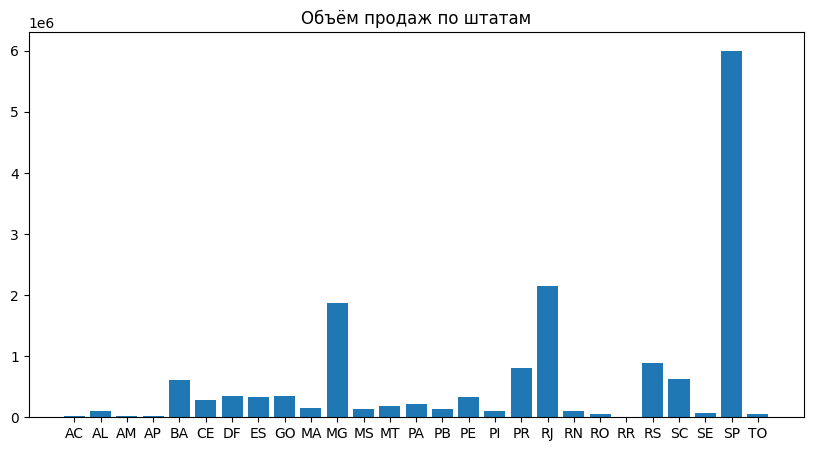

In [41]:
plt.figure(figsize=(10, 5))
plt.bar(revenues_by_states.index, revenues_by_states)
plt.title("Объём продаж по штатам")

In [42]:
top_states = top_states_by_revenue.index
no_top_states = revenues_by_states.drop(top_states)

Text(0.5, 1.0, 'Объём продаж по штатам, не включая три самых выдающихся')

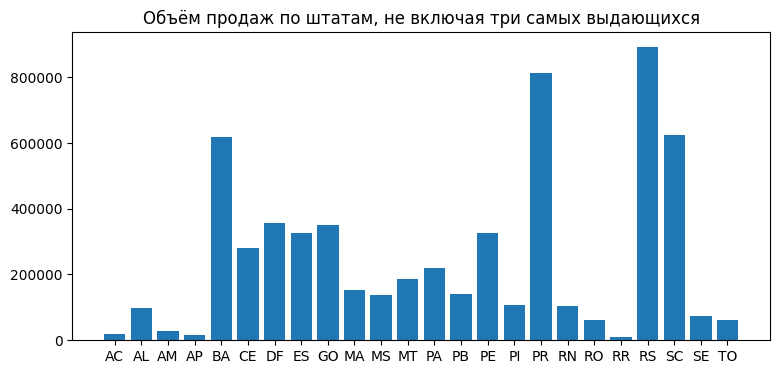

In [43]:
plt.figure(figsize=(9,4))
plt.bar(no_top_states.index, no_top_states)
plt.title("Объём продаж по штатам, не включая три самых выдающихся")

### Продажи по месяцам.

In [44]:
orders_payments['year_month'] = orders_payments['order_purchase_timestamp'].dt.strftime('%Y-%m')
orders_payments.groupby('year_month')['payment_value'].sum()

year_month
2016-09        252.24
2016-10      59090.48
2016-12         19.62
2017-01     138488.04
2017-02     291908.01
2017-03     449863.60
2017-04     417788.03
2017-05     592918.82
2017-06     511276.38
2017-07     592382.92
2017-08     674396.32
2017-09     727762.45
2017-10     779677.88
2017-11    1194882.80
2017-12     878401.48
2018-01    1115004.18
2018-02     992463.34
2018-03    1159652.12
2018-04    1160785.48
2018-05    1153982.15
2018-06    1023880.50
2018-07    1066540.75
2018-08    1022425.32
2018-09       4439.54
2018-10        589.67
Name: payment_value, dtype: float64

## Анализ продавцов

### Объём продаж.

In [45]:
orders_payments_items = orders_payments.merge(order_items_df, on='order_id')
orders_payments_items.groupby('seller_id')['payment_value'].sum()

seller_id
0015a82c2db000af6aaaf3ae2ecb0532     2748.06
001cca7ae9ae17fb1caed9dfb1094831    48349.22
001e6ad469a905060d959994f1b41e4f      267.94
002100f778ceb8431b7a1020ff7ab48f     2445.64
003554e2dce176b5555353e4f3555ac8      139.38
                                      ...   
ffcfefa19b08742c5d315f2791395ee5       79.52
ffdd9f82b9a447f6f8d4b91554cc7dd3     3607.52
ffeee66ac5d5a62fe688b9d26f83f534     2259.55
fffd5413c0700ac820c7069d66d98c89    12834.27
ffff564a4f9085cd26170f4732393726     1770.86
Name: payment_value, Length: 3095, dtype: float64

### Средний чек.

In [46]:
mean_price_by_sellers = orders_payments_items.groupby('seller_id')['payment_value'].mean()

In [47]:
print(mean_price_by_sellers.max(), mean_price_by_sellers.min())

9687.936 8.563333333333333


In [48]:
pd.cut(mean_price_by_sellers, bins = [1000 * x for x in range(11)]).value_counts()

payment_value
(0, 1000]        3007
(1000, 2000]       68
(2000, 3000]       12
(3000, 4000]        5
(6000, 7000]        2
(9000, 10000]       1
(5000, 6000]        0
(4000, 5000]        0
(7000, 8000]        0
(8000, 9000]        0
Name: count, dtype: int64

### Количество заказов.

In [49]:
num_orders_by_sellers = orders_payments_items.groupby('seller_id')['order_id'].count().value_counts()

In [50]:
interval_num_orders_by_sellers = pd.cut(num_orders_by_sellers,bins=[0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500])
interval_num_orders_by_sellers.value_counts()

count
(0, 50]       251
(50, 100]       8
(100, 150]      3
(200, 250]      1
(450, 500]      1
(300, 350]      1
(250, 300]      0
(150, 200]      0
(350, 400]      0
(400, 450]      0
Name: count, dtype: int64

In [51]:
print("Среднее количество заказов на продавца:", orders_payments_items.groupby('seller_id')['order_id'].count().mean())

Среднее количество заказов на продавца: 37.99709208400646


## Анализ отзывов

Text(0.5, 1.0, 'Распределение оценок')

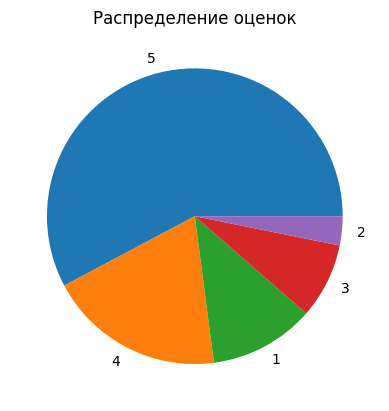

In [52]:
review_distribution = order_reviews_df['review_score'].value_counts(normalize=True)

plt.pie(review_distribution, labels=review_distribution.index)
plt.title("Распределение оценок")

### Корреляция оценок со стоимостью заказов.

In [53]:
reviews_with_prices = order_items_df.merge(order_reviews_df, on='order_id').groupby('order_id').agg({'review_score': 'mean', 'price': 'sum'})

In [54]:
pearson_corr, pearson_p = stats.pearsonr(
    reviews_with_prices['price'], 
    reviews_with_prices['review_score']
)

In [56]:
print("Коэффициент корреляции Пирсона:", pearson_corr)
print(f"p-value: {pearson_p:.4f}")

Коэффициент корреляции Пирсона: -0.039946060799181934
p-value: 0.0000


In [57]:
print("Объём выборки:", len(reviews_with_prices))

Объём выборки: 97917


Низкий коэффициент корреляции указывает на отсутствие линейной зависимости. Однако p-value < 0.05 указывает на то, что корреляция статистически значима. Причиной является большой объём выборки 97917.

In [58]:
r_squared = pearson_corr**2
print(f"Коэффициент детерминации R² = {r_squared:.6f}")
print(f"Цена объясняет всего {r_squared*100:.4f}% дисперсии оценок")

Коэффициент детерминации R² = 0.001596
Цена объясняет всего 0.1596% дисперсии оценок


In [66]:
from scipy.stats import spearmanr

spearman_corr, spearman_p = spearmanr(
    reviews_with_prices['price'], 
    reviews_with_prices['review_score']
)

print(f"Коэффициент Спирмена: {spearman_corr:.3f}")


Коэффициент Спирмена: -0.033


Значение коэффициента Спирмена близко к 0, как и коэффициент Пирсона.

### Корреляция оценок с категорией товаров.

In [59]:
reviews_with_items = order_items_df.merge(order_reviews_df, on='order_id')
reviews_with_categories = reviews_with_items.merge(products_df, on='product_id')
mean_review_by_categories = reviews_with_categories.groupby('product_category_name')['review_score'].mean().reset_index()
mean_review_by_categories = category_name_df.merge(mean_review_by_categories, on='product_category_name').drop('product_category_name', axis=1)

In [60]:
mean_review_by_categories 

,product_category_name_english,review_score
0,health_beauty,4.142768
1,computers_accessories,3.930819
2,auto,4.065512
3,bed_bath_table,3.895663
4,furniture_decor,3.903493
...,...,...
66,flowers,4.419355
67,arts_and_craftmanship,4.125000
68,diapers_and_hygiene,3.256410
69,fashion_childrens_clothes,4.500000


In [61]:
top_3_categories_by_low_score = mean_review_by_categories.nsmallest(3, columns='review_score')
top_3_categories_by_low_score

,product_category_name_english,review_score
70,security_and_services,2.500000
68,diapers_and_hygiene,3.256410
30,office_furniture,3.493183
